# INSE 6450 — Milestone 4: Continual Learning & Human-in-the-Loop
## RobustOps: CI/CD-Integrated Adversarial Robustness Testing and ML Risk Scoring
**Cynthia Musila — 40311473**  
**Concordia University — Winter 2026**  




In [1]:

# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
import warnings
import time
import hashlib
import json
import copy

warnings.filterwarnings('ignore')
np.random.seed(42)


try:
    from xgboost import XGBClassifier, XGBRegressor
    USE_XGBOOST = True
    print("Using XGBoost")
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
    USE_XGBOOST = False
    print("XGBoost not available, using sklearn GradientBoosting as substitute")

print("Setup complete.")


Using XGBoost
Setup complete.


## 1. Data Loading and Baseline Model Training


In [2]:

# 1.1 Load Adult Income Dataset
print("Loading Adult Income dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
           'marital_status', 'occupation', 'relationship', 'race', 'sex',
           'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

try:
    adult_df = pd.read_csv(url, names=columns, sep=',\s*', engine='python', na_values='?')
except:
    print("Generating synthetic Adult Income-like dataset...")
    n = 32561
    adult_df = pd.DataFrame({
        'age': np.random.normal(38.5, 13.5, n).astype(int).clip(17, 90),
        'workclass': np.random.choice(['Private', 'Self-emp', 'Gov', 'Other'], n, p=[0.7, 0.1, 0.13, 0.07]),
        'fnlwgt': np.random.normal(189778, 105549, n).astype(int),
        'education': np.random.choice(['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate', 'Other'], n),
        'education_num': np.random.normal(10, 2.6, n).clip(1, 16).astype(int),
        'marital_status': np.random.choice(['Married', 'Never-married', 'Divorced', 'Other'], n, p=[0.46, 0.33, 0.14, 0.07]),
        'occupation': np.random.choice(['Prof-specialty', 'Craft-repair', 'Exec-managerial', 'Adm-clerical', 'Sales', 'Other'], n),
        'relationship': np.random.choice(['Husband', 'Not-in-family', 'Own-child', 'Unmarried', 'Wife', 'Other'], n),
        'race': np.random.choice(['White', 'Black', 'Asian-Pac-Islander', 'Other'], n, p=[0.85, 0.1, 0.03, 0.02]),
        'sex': np.random.choice(['Male', 'Female'], n, p=[0.67, 0.33]),
        'capital_gain': np.random.exponential(1078, n).clip(0, 99999).astype(int),
        'capital_loss': np.random.exponential(87, n).clip(0, 4356).astype(int),
        'hours_per_week': np.random.normal(40.4, 12.3, n).clip(1, 99).astype(int),
        'native_country': np.random.choice(['US', 'Other'], n, p=[0.90, 0.10]),
        'income': np.random.choice(['<=50K', '>50K'], n, p=[0.752, 0.248]),
    })

adult_df.dropna(inplace=True)
print(f"Adult Income: {len(adult_df)} samples, {adult_df['income'].value_counts().to_dict()}")

cat_cols = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
scaler_cls = StandardScaler()

X_cat = encoder.fit_transform(adult_df[cat_cols])
X_num = scaler_cls.fit_transform(adult_df[num_cols].values)
X_adult = np.hstack([X_num, X_cat])
y_adult = (adult_df['income'].str.strip() == '>50K').astype(int).values

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_adult, y_adult, test_size=0.15, random_state=42, stratify=y_adult)
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_train_cls, y_train_cls, test_size=0.176, random_state=42, stratify=y_train_cls)

print(f"Train: {len(X_train_cls)}, Val: {len(X_val_cls)}, Test: {len(X_test_cls)}")
print(f"Features: {X_adult.shape[1]}")


Loading Adult Income dataset...
Adult Income: 30162 samples, {'<=50K': 22654, '>50K': 7508}
Train: 21124, Val: 4513, Test: 4525
Features: 96


In [3]:

# 1.2 Load California Housing Dataset
print("Loading California Housing dataset...")
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

scaler_reg = StandardScaler()
X_housing_scaled = scaler_reg.fit_transform(X_housing)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_housing_scaled, y_housing, test_size=0.15, random_state=42)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_train_reg, y_train_reg, test_size=0.176, random_state=42)

print(f"Train: {len(X_train_reg)}, Val: {len(X_val_reg)}, Test: {len(X_test_reg)}")
print(f"Features: {X_housing.shape[1]}")


Loading California Housing dataset...
Train: 14456, Val: 3088, Test: 3096
Features: 8


In [4]:

# 1.3 Train Baseline Tabular Models
print("\n" + "=" * 70)
print("TRAINING BASELINE MODELS")
print("=" * 70)

t0 = time.time()
if USE_XGBOOST:
    clf_baseline = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                  random_state=42, eval_metric='logloss', verbosity=0)
else:
    clf_baseline = GradientBoostingClassifier(n_estimators=100, max_depth=6,
                                              learning_rate=0.1, random_state=42)
clf_baseline.fit(X_train_cls, y_train_cls)
cls_train_time = time.time() - t0

y_pred_cls = clf_baseline.predict(X_test_cls)
cls_acc = accuracy_score(y_test_cls, y_pred_cls)
cls_f1 = f1_score(y_test_cls, y_pred_cls, average='macro')

print(f"\nTabular Classification (XGBoost):")
print(f"  Clean Accuracy: {cls_acc:.4f}")
print(f"  Clean F1 Macro: {cls_f1:.4f}")
print(f"  Training Time:  {cls_train_time:.2f}s")

t0 = time.time()
if USE_XGBOOST:
    reg_baseline = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 random_state=42, verbosity=0)
else:
    reg_baseline = GradientBoostingRegressor(n_estimators=200, max_depth=6,
                                              learning_rate=0.1, random_state=42)
reg_baseline.fit(X_train_reg, y_train_reg)
reg_train_time = time.time() - t0

y_pred_reg = reg_baseline.predict(X_test_reg)
reg_r2 = r2_score(y_test_reg, y_pred_reg)
reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f"\nTabular Regression (XGBoost):")
print(f"  Clean R\u00B2:       {reg_r2:.4f}")
print(f"  Clean RMSE:     {reg_rmse:.4f}")
print(f"  Training Time:  {reg_train_time:.2f}s")



TRAINING BASELINE MODELS

Tabular Classification (XGBoost):
  Clean Accuracy: 0.8694
  Clean F1 Macro: 0.8147
  Training Time:  3.15s

Tabular Regression (XGBoost):
  Clean R²:       0.8346
  Clean RMSE:     0.4656
  Training Time:  2.52s


## 2. RobustOps Core Components


In [5]:

# 2.1 Risk Scoring Functions (from Milestones 2-3)

def compute_classification_risk(model, X_clean, y_true, noise_sigma=0.1):
    y_clean = model.predict(X_clean)
    clean_acc = accuracy_score(y_true, y_clean)
    if hasattr(model, 'predict_proba'):
        clean_probs = model.predict_proba(X_clean)
        clean_conf = np.max(clean_probs, axis=1).mean()
    else:
        clean_conf = 0.9

    X_adv = X_clean + np.random.normal(0, noise_sigma, X_clean.shape)
    y_adv = model.predict(X_adv)
    adv_acc = accuracy_score(y_true, y_adv)
    if hasattr(model, 'predict_proba'):
        adv_probs = model.predict_proba(X_adv)
        adv_conf = np.max(adv_probs, axis=1).mean()
    else:
        adv_conf = 0.85

    acc_drop = (clean_acc - adv_acc) / max(clean_acc, 0.01)
    conf_drop = clean_conf - adv_conf
    correct_clean = (y_clean == y_true)
    wrong_adv = (y_adv != y_true)
    asr = (correct_clean & wrong_adv).sum() / max(correct_clean.sum(), 1)

    classes = np.unique(y_true)
    class_asrs = []
    for c_val in classes:
        mask = (y_true == c_val)
        correct_c = (y_clean[mask] == y_true[mask])
        wrong_c = (y_adv[mask] != y_true[mask])
        if correct_c.sum() > 0:
            class_asrs.append((correct_c & wrong_c).sum() / correct_c.sum())
    worst_class_asr = max(class_asrs) if class_asrs else 0

    risk = 0.35 * acc_drop + 0.25 * conf_drop + 0.25 * asr + 0.15 * worst_class_asr
    risk = max(0, min(1, risk))
    gate = "PASS" if risk < 0.5 else "BLOCK"
    return {'clean_acc': clean_acc, 'adv_acc': adv_acc, 'asr': asr,
            'risk_score': risk, 'gate': gate}

def compute_regression_risk(model, X_clean, y_true, noise_sigma=0.1):
    y_clean = model.predict(X_clean)
    clean_r2 = r2_score(y_true, y_clean)
    clean_rmse = np.sqrt(mean_squared_error(y_true, y_clean))

    X_adv = X_clean + np.random.normal(0, noise_sigma, X_clean.shape)
    y_adv = model.predict(X_adv)
    adv_r2 = r2_score(y_true, y_adv)
    adv_rmse = np.sqrt(mean_squared_error(y_true, y_adv))

    y_std = np.std(y_true)
    r2_drop = (clean_r2 - adv_r2) / max(clean_r2, 0.01)
    rmse_inc = (adv_rmse - clean_rmse) / max(clean_rmse, 0.01)
    pred_shift = np.mean(np.abs(y_adv - y_clean)) / max(y_std, 0.01)
    max_shift = np.max(np.abs(y_adv - y_clean)) / max(y_std, 0.01)

    risk = 0.30 * r2_drop + 0.25 * rmse_inc + 0.25 * pred_shift + 0.20 * max_shift
    risk = max(0, risk)
    gate = "PASS" if risk < 0.5 else "BLOCK"
    return {'clean_r2': clean_r2, 'adv_r2': adv_r2, 'clean_rmse': clean_rmse,
            'adv_rmse': adv_rmse, 'risk_score': risk, 'gate': gate}

print("=" * 70)
print("BASELINE ADVERSARIAL EVALUATION")
print("=" * 70)
cls_risk = compute_classification_risk(clf_baseline, X_test_cls, y_test_cls, noise_sigma=0.1)
print(f"\nClassification Risk: {cls_risk['risk_score']:.4f} -> {cls_risk['gate']}")
print(f"  Clean Acc: {cls_risk['clean_acc']:.4f}, Adv Acc: {cls_risk['adv_acc']:.4f}, ASR: {cls_risk['asr']:.4f}")

reg_risk = compute_regression_risk(reg_baseline, X_test_reg, y_test_reg, noise_sigma=0.1)
print(f"\nRegression Risk: {reg_risk['risk_score']:.4f} -> {reg_risk['gate']}")
print(f"  Clean R\u00B2: {reg_risk['clean_r2']:.4f}, Adv R\u00B2: {reg_risk['adv_r2']:.4f}")


BASELINE ADVERSARIAL EVALUATION

Classification Risk: 0.1235 -> PASS
  Clean Acc: 0.8694, Adv Acc: 0.8086, ASR: 0.1129

Regression Risk: 0.8935 -> BLOCK
  Clean R²: 0.8346, Adv R²: 0.5048


In [6]:

# 2.2 Drift Detection (PSI)

def compute_psi(reference, current, bins=10):
    ref_hist, bin_edges = np.histogram(reference, bins=bins, density=True)
    cur_hist, _ = np.histogram(current, bins=bin_edges, density=True)
    ref_hist = np.clip(ref_hist, 1e-6, None)
    cur_hist = np.clip(cur_hist, 1e-6, None)
    ref_pct = ref_hist / ref_hist.sum()
    cur_pct = cur_hist / cur_hist.sum()
    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return psi

def detect_drift(X_ref, X_new, threshold=0.2, min_features=2):
    n_features = X_ref.shape[1]
    psi_values = []
    for i in range(min(n_features, 20)):
        psi = compute_psi(X_ref[:, i], X_new[:, i])
        psi_values.append(psi)
    drifted_features = sum(1 for p_val in psi_values if p_val > threshold)
    drift_detected = drifted_features >= min_features
    mean_psi = np.mean(psi_values)
    return drift_detected, mean_psi, drifted_features

print("Drift detection module loaded.")


Drift detection module loaded.


## 3. Continual Learning Module — Tabular Experiments


In [7]:

# 3.1 Replay Buffer + CL Engine

class ReplayBuffer:
    def __init__(self, max_size=500):
        self.max_size = max_size
        self.X = None
        self.y = None
        self.weights = None
        self.count = 0
        self.version = 0

    def initialize(self, X, y, sample_size=None):
        if sample_size is None:
            sample_size = min(self.max_size, len(X))
        idx = np.random.choice(len(X), size=sample_size, replace=False)
        self.X = X[idx].copy()
        self.y = y[idx].copy()
        self.weights = np.ones(len(self.X))
        self.count = len(self.X)
        self.version = 1
        print(f"  Buffer initialized: {len(self.X)} samples, version {self.version}")

    def update(self, X_new, y_new, replace_frac=0.2, human_verified=False):
        n_replace = int(len(self.X) * replace_frac)
        n_new = min(n_replace, len(X_new))
        if n_new == 0:
            return
        idx_new = np.random.choice(len(X_new), size=n_new, replace=False)
        idx_replace = np.random.choice(len(self.X), size=n_new, replace=False)
        self.X[idx_replace] = X_new[idx_new]
        self.y[idx_replace] = y_new[idx_new]
        weight = 2.0 if human_verified else 1.0
        self.weights[idx_replace] = weight
        self.count += n_new
        self.version += 1

    def get_training_data(self, X_new, y_new, replay_frac=0.8):
        n_replay = int(len(self.X) * replay_frac)
        probs = self.weights / self.weights.sum()
        idx = np.random.choice(len(self.X), size=n_replay, replace=True, p=probs)
        X_replay = self.X[idx]
        y_replay = self.y[idx]
        X_combined = np.vstack([X_replay, X_new])
        y_combined = np.concatenate([y_replay, y_new])
        return X_combined, y_combined

    def get_checksum(self):
        data_bytes = self.X.tobytes() + self.y.tobytes()
        return hashlib.sha256(data_bytes).hexdigest()[:12]


class ContinualLearner:
    def __init__(self, task_type='classification', buffer_size=500):
        self.task_type = task_type
        self.buffer = ReplayBuffer(max_size=buffer_size)
        self.model = None
        self.model_versions = []

    def initialize(self, model, X_train, y_train):
        self.model = model
        self.buffer.initialize(X_train, y_train)
        print(f"  ContinualLearner initialized ({self.task_type})")

    def simulate_drift(self, X, y, shift_magnitude=0.5, class_rebalance=False):
        X_drifted = X.copy()
        n_shift = min(6, X.shape[1])
        for i in range(n_shift):
            X_drifted[:, i] += shift_magnitude * np.std(X[:, i])
        y_drifted = y.copy()
        if class_rebalance and self.task_type == 'classification':
            pos_idx = np.where(y == 1)[0]
            neg_idx = np.where(y == 0)[0]
            target_pos = int(0.4 * len(y))
            if len(pos_idx) < target_pos:
                extra = np.random.choice(pos_idx, target_pos - len(pos_idx), replace=True)
                drop = np.random.choice(neg_idx, len(extra), replace=False)
                keep = np.setdiff1d(np.arange(len(y)), drop)
                keep = np.concatenate([keep, extra])
                X_drifted = X_drifted[keep]
                y_drifted = y_drifted[keep]
        return X_drifted, y_drifted

    def retrain(self, X_new, y_new, use_replay=True):
        t0 = time.time()
        if use_replay:
            X_train, y_train = self.buffer.get_training_data(X_new, y_new)
        else:
            X_train, y_train = X_new, y_new
        if USE_XGBOOST:
            if self.task_type == 'classification':
                new_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                           random_state=42, eval_metric='logloss', verbosity=0)
            else:
                new_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                          random_state=42, verbosity=0)
        else:
            if self.task_type == 'classification':
                new_model = GradientBoostingClassifier(n_estimators=100, max_depth=6,
                                                        learning_rate=0.1, random_state=42)
            else:
                new_model = GradientBoostingRegressor(n_estimators=200, max_depth=6,
                                                       learning_rate=0.1, random_state=42)
        new_model.fit(X_train, y_train)
        update_time = time.time() - t0
        self.model = new_model
        self.buffer.update(X_new, y_new, replace_frac=0.2)
        self.model_versions.append({
            'version': len(self.model_versions) + 1,
            'buffer_checksum': self.buffer.get_checksum(),
            'buffer_version': self.buffer.version,
            'update_time': update_time,
            'train_size': len(X_train),
        })
        return update_time

    def evaluate(self, X_test, y_test, X_orig_test, y_orig_test, noise_sigma=0.1):
        if self.task_type == 'classification':
            y_pred_drift = self.model.predict(X_test)
            drift_acc = accuracy_score(y_test, y_pred_drift)
            drift_f1 = f1_score(y_test, y_pred_drift, average='macro')
            y_pred_orig = self.model.predict(X_orig_test)
            orig_acc = accuracy_score(y_orig_test, y_pred_orig)
            orig_f1 = f1_score(y_orig_test, y_pred_orig, average='macro')
            risk_result = compute_classification_risk(self.model, X_orig_test, y_orig_test, noise_sigma)
            return {'drifted_acc': drift_acc, 'drifted_f1': drift_f1,
                    'original_acc': orig_acc, 'original_f1': orig_f1,
                    'risk_score': risk_result['risk_score'], 'gate': risk_result['gate']}
        else:
            y_pred_drift = self.model.predict(X_test)
            drift_r2 = r2_score(y_test, y_pred_drift)
            drift_rmse = np.sqrt(mean_squared_error(y_test, y_pred_drift))
            y_pred_orig = self.model.predict(X_orig_test)
            orig_r2 = r2_score(y_orig_test, y_pred_orig)
            orig_rmse = np.sqrt(mean_squared_error(y_orig_test, y_pred_orig))
            risk_result = compute_regression_risk(self.model, X_orig_test, y_orig_test, noise_sigma)
            return {'drifted_r2': drift_r2, 'drifted_rmse': drift_rmse,
                    'original_r2': orig_r2, 'original_rmse': orig_rmse,
                    'risk_score': risk_result['risk_score'], 'gate': risk_result['gate']}

print("ReplayBuffer and ContinualLearner classes defined.")


ReplayBuffer and ContinualLearner classes defined.


In [8]:

# 3.2 Classification CL Experiment — 3 Drift Events
print("=" * 70)
print("CONTINUAL LEARNING EXPERIMENT — TABULAR CLASSIFICATION")
print("=" * 70)

cl_cls = ContinualLearner(task_type='classification')
cl_cls.initialize(clf_baseline, X_train_cls, y_train_cls)

drift_magnitudes = [0.3, 0.5, 0.8]
class_rebalance = [False, False, True]
cls_results = []

baseline_eval = cl_cls.evaluate(X_test_cls, y_test_cls, X_test_cls, y_test_cls)
cls_results.append({
    'stage': 'Baseline', 'drifted_acc': baseline_eval['drifted_acc'],
    'drifted_f1': baseline_eval['drifted_f1'], 'original_acc': baseline_eval['original_acc'],
    'original_f1': baseline_eval['original_f1'], 'risk': baseline_eval['risk_score'],
    'gate': baseline_eval['gate'], 'update_time': 0
})
print(f"\nBaseline: Acc={baseline_eval['drifted_acc']:.4f}, F1={baseline_eval['drifted_f1']:.4f}, "
      f"Risk={baseline_eval['risk_score']:.4f} [{baseline_eval['gate']}]")

for i, (mag, rebal) in enumerate(zip(drift_magnitudes, class_rebalance)):
    print(f"\n--- Drift Event {i+1} (shift={mag}\u03C3, rebalance={rebal}) ---")
    X_drift_test, y_drift_test = cl_cls.simulate_drift(X_test_cls, y_test_cls, mag, rebal)

    before = cl_cls.evaluate(X_drift_test, y_drift_test, X_test_cls, y_test_cls)
    cls_results.append({
        'stage': f'Drift {i+1} (before)', 'drifted_acc': before['drifted_acc'],
        'drifted_f1': before['drifted_f1'], 'original_acc': before['original_acc'],
        'original_f1': before['original_f1'], 'risk': before['risk_score'],
        'gate': before['gate'], 'update_time': 0
    })
    print(f"  Before CL: Drifted Acc={before['drifted_acc']:.4f}, Orig Acc={before['original_acc']:.4f}")

    X_drift_train, y_drift_train = cl_cls.simulate_drift(X_train_cls, y_train_cls, mag, rebal)
    n_new = min(300, len(X_drift_train))
    idx = np.random.choice(len(X_drift_train), n_new, replace=False)
    update_time = cl_cls.retrain(X_drift_train[idx], y_drift_train[idx], use_replay=True)

    after = cl_cls.evaluate(X_drift_test, y_drift_test, X_test_cls, y_test_cls)
    cls_results.append({
        'stage': f'Drift {i+1} (after)', 'drifted_acc': after['drifted_acc'],
        'drifted_f1': after['drifted_f1'], 'original_acc': after['original_acc'],
        'original_f1': after['original_f1'], 'risk': after['risk_score'],
        'gate': after['gate'], 'update_time': update_time
    })
    print(f"  After CL:  Drifted Acc={after['drifted_acc']:.4f}, Orig Acc={after['original_acc']:.4f}, "
          f"Risk={after['risk_score']:.4f}, Time={update_time:.2f}s")

print("\n" + "=" * 70)
print("CLASSIFICATION CL SUMMARY")
print("=" * 70)
print(f"{'Stage':<22} {'Drift Acc':>10} {'Drift F1':>10} {'Orig Acc':>10} {'Risk':>8} {'Gate':>6} {'Time':>8}")
print("-" * 76)
for r in cls_results:
    print(f"{r['stage']:<22} {r['drifted_acc']:>10.4f} {r['drifted_f1']:>10.4f} "
          f"{r['original_acc']:>10.4f} {r['risk']:>8.4f} {r['gate']:>6} {r['update_time']:>7.2f}s")


CONTINUAL LEARNING EXPERIMENT — TABULAR CLASSIFICATION
  Buffer initialized: 500 samples, version 1
  ContinualLearner initialized (classification)

Baseline: Acc=0.8694, F1=0.8147, Risk=0.1262 [PASS]

--- Drift Event 1 (shift=0.3σ, rebalance=False) ---
  Before CL: Drifted Acc=0.8044, Orig Acc=0.8694
  After CL:  Drifted Acc=0.8214, Orig Acc=0.8356, Risk=0.1020, Time=0.29s

--- Drift Event 2 (shift=0.5σ, rebalance=False) ---
  Before CL: Drifted Acc=0.8106, Orig Acc=0.8356
  After CL:  Drifted Acc=0.8084, Orig Acc=0.8190, Risk=0.0957, Time=0.32s

--- Drift Event 3 (shift=0.8σ, rebalance=True) ---
  Before CL: Drifted Acc=0.7744, Orig Acc=0.8190
  After CL:  Drifted Acc=0.7987, Orig Acc=0.8301, Risk=0.0920, Time=0.30s

CLASSIFICATION CL SUMMARY
Stage                   Drift Acc   Drift F1   Orig Acc     Risk   Gate     Time
----------------------------------------------------------------------------
Baseline                   0.8694     0.8147     0.8694   0.1262   PASS    0.00s
Drift 

In [9]:

# 3.3 Regression CL Experiment — 3 Drift Events
print("=" * 70)
print("CONTINUAL LEARNING EXPERIMENT — TABULAR REGRESSION")
print("=" * 70)

cl_reg = ContinualLearner(task_type='regression')
cl_reg.initialize(reg_baseline, X_train_reg, y_train_reg)

reg_results = []

baseline_reg = cl_reg.evaluate(X_test_reg, y_test_reg, X_test_reg, y_test_reg)
reg_results.append({
    'stage': 'Baseline', 'drifted_r2': baseline_reg['drifted_r2'],
    'drifted_rmse': baseline_reg['drifted_rmse'], 'original_r2': baseline_reg['original_r2'],
    'original_rmse': baseline_reg['original_rmse'],
    'risk': baseline_reg['risk_score'], 'gate': baseline_reg['gate'], 'update_time': 0
})

for i, mag in enumerate([0.3, 0.5, 0.8]):
    X_drift_test, y_drift_test = cl_reg.simulate_drift(X_test_reg, y_test_reg, mag)

    before = cl_reg.evaluate(X_drift_test, y_drift_test, X_test_reg, y_test_reg)
    reg_results.append({
        'stage': f'Drift {i+1} (before)', 'drifted_r2': before['drifted_r2'],
        'drifted_rmse': before['drifted_rmse'], 'original_r2': before['original_r2'],
        'original_rmse': before['original_rmse'],
        'risk': before['risk_score'], 'gate': before['gate'], 'update_time': 0
    })

    X_drift_train, y_drift_train = cl_reg.simulate_drift(X_train_reg, y_train_reg, mag)
    n_new = min(300, len(X_drift_train))
    idx = np.random.choice(len(X_drift_train), n_new, replace=False)
    update_time = cl_reg.retrain(X_drift_train[idx], y_drift_train[idx], use_replay=True)

    after = cl_reg.evaluate(X_drift_test, y_drift_test, X_test_reg, y_test_reg)
    reg_results.append({
        'stage': f'Drift {i+1} (after)', 'drifted_r2': after['drifted_r2'],
        'drifted_rmse': after['drifted_rmse'], 'original_r2': after['original_r2'],
        'original_rmse': after['original_rmse'],
        'risk': after['risk_score'], 'gate': after['gate'], 'update_time': update_time
    })

print(f"\n{'Stage':<22} {'Drift R\u00B2':>10} {'Drift RMSE':>12} {'Orig R\u00B2':>10} {'Risk':>8} {'Gate':>6} {'Time':>8}")
print("-" * 78)
for r in reg_results:
    print(f"{r['stage']:<22} {r['drifted_r2']:>10.4f} {r['drifted_rmse']:>12.4f} "
          f"{r['original_r2']:>10.4f} {r['risk']:>8.4f} {r['gate']:>6} {r['update_time']:>7.2f}s")


CONTINUAL LEARNING EXPERIMENT — TABULAR REGRESSION
  Buffer initialized: 500 samples, version 1
  ContinualLearner initialized (regression)

Stage                    Drift R²   Drift RMSE    Orig R²     Risk   Gate     Time
------------------------------------------------------------------------------
Baseline                   0.8346       0.4656     0.8346   0.9710  BLOCK    0.00s
Drift 1 (before)           0.7917       0.5224     0.8346   0.9664  BLOCK    0.00s
Drift 1 (after)            0.6333       0.6932     0.6634   0.8677  BLOCK    1.37s
Drift 2 (before)           0.4060       0.8823     0.6634   0.8344  BLOCK    0.00s
Drift 2 (after)            0.5516       0.7666     0.6686   0.9246  BLOCK    0.97s
Drift 3 (before)           0.1736       1.0407     0.6686   0.9614  BLOCK    0.00s
Drift 3 (after)            0.4427       0.8546     0.6303   0.7133  BLOCK    4.36s


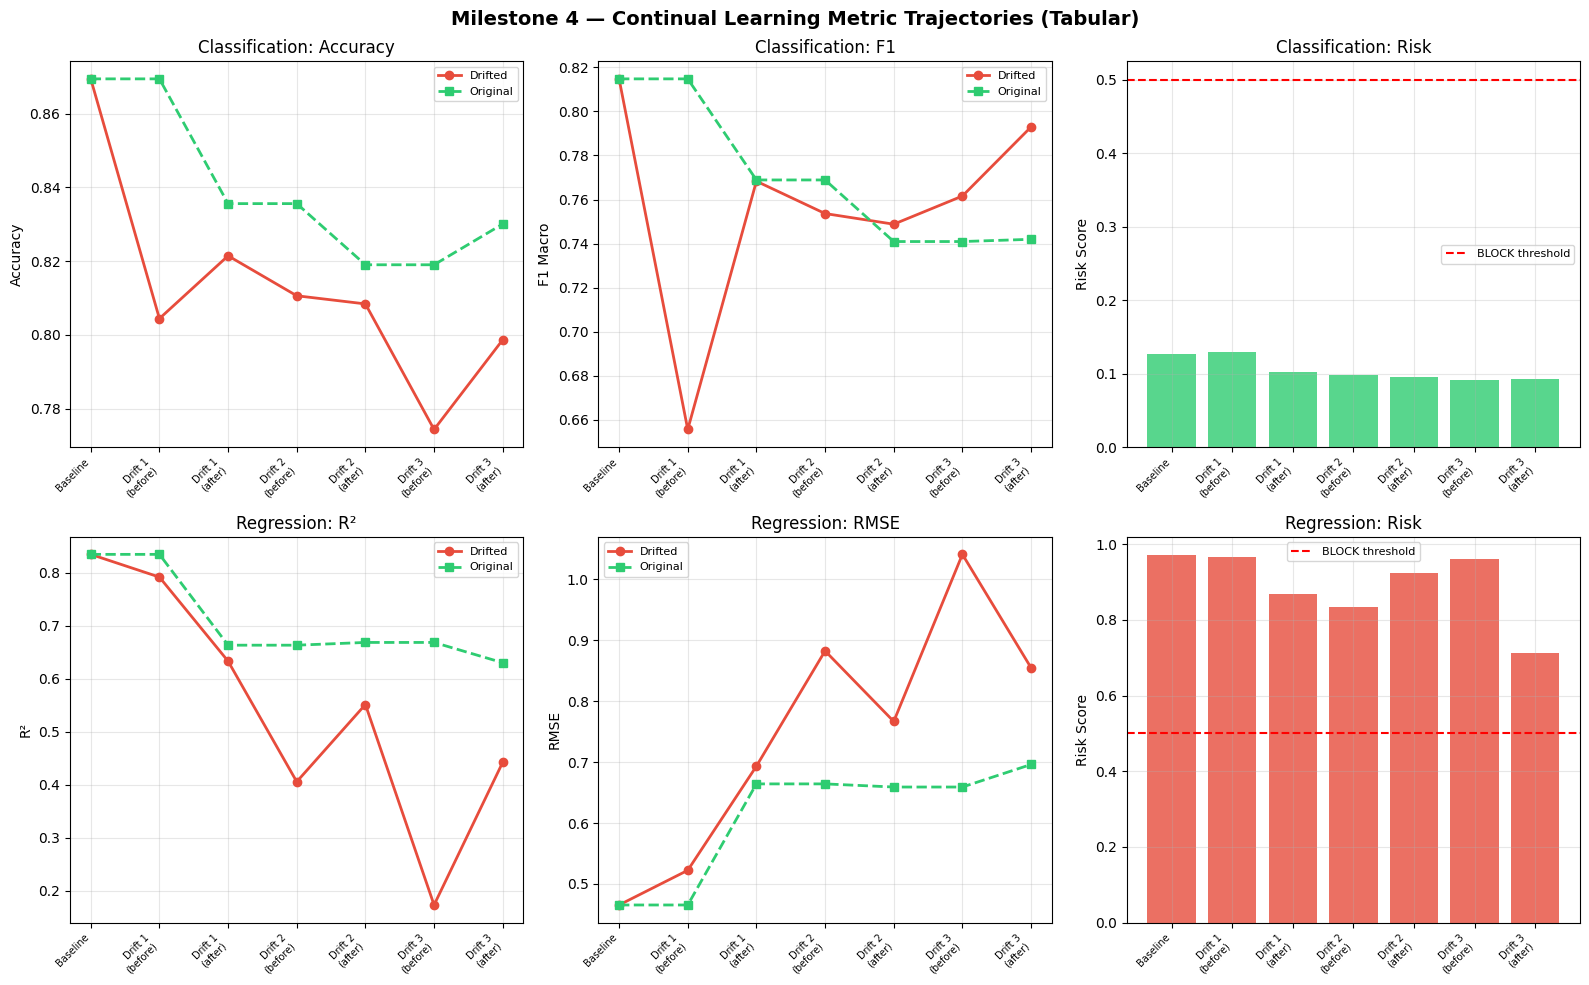

In [10]:

# 3.4 Tabular CL Metric Trajectory Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Milestone 4 — Continual Learning Metric Trajectories (Tabular)', fontsize=14, fontweight='bold')

stages_cls = [r['stage'] for r in cls_results]
x_cls = range(len(stages_cls))

axes[0, 0].plot(x_cls, [r['drifted_acc'] for r in cls_results], 'o-', color='#e74c3c', linewidth=2, label='Drifted')
axes[0, 0].plot(x_cls, [r['original_acc'] for r in cls_results], 's--', color='#2ecc71', linewidth=2, label='Original')
axes[0, 0].set_title('Classification: Accuracy'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(fontsize=8); axes[0, 0].set_xticks(x_cls)
axes[0, 0].set_xticklabels([s.replace(' (', '\n(') for s in stages_cls], fontsize=7, rotation=45, ha='right')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x_cls, [r['drifted_f1'] for r in cls_results], 'o-', color='#e74c3c', linewidth=2, label='Drifted')
axes[0, 1].plot(x_cls, [r['original_f1'] for r in cls_results], 's--', color='#2ecc71', linewidth=2, label='Original')
axes[0, 1].set_title('Classification: F1'); axes[0, 1].set_ylabel('F1 Macro')
axes[0, 1].legend(fontsize=8); axes[0, 1].set_xticks(x_cls)
axes[0, 1].set_xticklabels([s.replace(' (', '\n(') for s in stages_cls], fontsize=7, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].bar(x_cls, [r['risk'] for r in cls_results], color=['#2ecc71' if r['gate']=='PASS' else '#e74c3c' for r in cls_results], alpha=0.8)
axes[0, 2].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='BLOCK threshold')
axes[0, 2].set_title('Classification: Risk'); axes[0, 2].set_ylabel('Risk Score')
axes[0, 2].legend(fontsize=8); axes[0, 2].set_xticks(x_cls)
axes[0, 2].set_xticklabels([s.replace(' (', '\n(') for s in stages_cls], fontsize=7, rotation=45, ha='right')
axes[0, 2].grid(True, alpha=0.3)

stages_reg = [r['stage'] for r in reg_results]
x_reg = range(len(stages_reg))

axes[1, 0].plot(x_reg, [r['drifted_r2'] for r in reg_results], 'o-', color='#e74c3c', linewidth=2, label='Drifted')
axes[1, 0].plot(x_reg, [r['original_r2'] for r in reg_results], 's--', color='#2ecc71', linewidth=2, label='Original')
axes[1, 0].set_title('Regression: R\u00B2'); axes[1, 0].set_ylabel('R\u00B2')
axes[1, 0].legend(fontsize=8); axes[1, 0].set_xticks(x_reg)
axes[1, 0].set_xticklabels([s.replace(' (', '\n(') for s in stages_reg], fontsize=7, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x_reg, [r['drifted_rmse'] for r in reg_results], 'o-', color='#e74c3c', linewidth=2, label='Drifted')
axes[1, 1].plot(x_reg, [r['original_rmse'] for r in reg_results], 's--', color='#2ecc71', linewidth=2, label='Original')
axes[1, 1].set_title('Regression: RMSE'); axes[1, 1].set_ylabel('RMSE')
axes[1, 1].legend(fontsize=8); axes[1, 1].set_xticks(x_reg)
axes[1, 1].set_xticklabels([s.replace(' (', '\n(') for s in stages_reg], fontsize=7, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].bar(x_reg, [r['risk'] for r in reg_results], color=['#2ecc71' if r['gate']=='PASS' else '#e74c3c' for r in reg_results], alpha=0.8)
axes[1, 2].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='BLOCK threshold')
axes[1, 2].set_title('Regression: Risk'); axes[1, 2].set_ylabel('Risk Score')
axes[1, 2].legend(fontsize=8); axes[1, 2].set_xticks(x_reg)
axes[1, 2].set_xticklabels([s.replace(' (', '\n(') for s in stages_reg], fontsize=7, rotation=45, ha='right')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Active Learning + Human-in-the-Loop


In [11]:

# 4.1 Active Learning Module

class ActiveLearner:
    def __init__(self, budget=50):
        self.budget = budget
        self.query_history = []

    def select_samples(self, model, X_pool, task_type='classification'):
        t0 = time.time()
        if task_type == 'classification' and hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_pool)
            sorted_probs = np.sort(probs, axis=1)
            margins = sorted_probs[:, -1] - sorted_probs[:, -2]
        else:
            preds = model.predict(X_pool)
            margins = np.abs(preds - np.mean(preds))

        k = min(2 * self.budget, len(X_pool))
        uncertain_idx = np.argsort(margins)[:k]

        X_candidates = X_pool[uncertain_idx]
        n_clusters = min(self.budget, len(X_candidates))

        if n_clusters > 1:
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=3)
            cluster_labels = kmeans.fit_predict(X_candidates)
            selected = []
            for c_val in range(n_clusters):
                cluster_mask = cluster_labels == c_val
                cluster_margins = margins[uncertain_idx[cluster_mask]]
                most_uncertain = np.argmin(cluster_margins)
                original_idx = uncertain_idx[cluster_mask][most_uncertain]
                selected.append(original_idx)
        else:
            selected = uncertain_idx[:self.budget].tolist()

        query_time = time.time() - t0
        self.query_history.append({'n_queried': len(selected), 'query_time': query_time})
        return np.array(selected), query_time

print("ActiveLearner class defined.")


ActiveLearner class defined.


In [12]:

# 4.2 Active Learning + CL Simulation — 5 Cycles
print("=" * 70)
print("ACTIVE LEARNING + CONTINUAL LEARNING SIMULATION")
print("5 Cycles, Tabular Classification, Drift +0.5\u03C3")
print("=" * 70)

cl_al = ContinualLearner(task_type='classification')
cl_al.initialize(clf_baseline, X_train_cls, y_train_cls)
al = ActiveLearner(budget=50)

X_drift_test_al, y_drift_test_al = cl_al.simulate_drift(X_test_cls, y_test_cls, 0.5)
X_drift_train_al, y_drift_train_al = cl_al.simulate_drift(X_train_cls, y_train_cls, 0.5)

al_results = []

eval_0 = cl_al.evaluate(X_drift_test_al, y_drift_test_al, X_test_cls, y_test_cls)
al_results.append({'cycle': 0, 'type': 'Baseline (no CL)', 'drifted_acc': eval_0['drifted_acc'],
    'drifted_f1': eval_0['drifted_f1'], 'original_acc': eval_0['original_acc'],
    'risk': eval_0['risk_score'], 'n_labeled': 0, 'update_time': 0, 'query_time': 0})
print(f"\nCycle 0 (Baseline): Drift Acc={eval_0['drifted_acc']:.4f}, Orig Acc={eval_0['original_acc']:.4f}")

n_new = 300
idx = np.random.choice(len(X_drift_train_al), n_new, replace=False)
ut = cl_al.retrain(X_drift_train_al[idx], y_drift_train_al[idx])
eval_cl = cl_al.evaluate(X_drift_test_al, y_drift_test_al, X_test_cls, y_test_cls)
al_results.append({'cycle': 1, 'type': 'CL only (no AL)', 'drifted_acc': eval_cl['drifted_acc'],
    'drifted_f1': eval_cl['drifted_f1'], 'original_acc': eval_cl['original_acc'],
    'risk': eval_cl['risk_score'], 'n_labeled': 0, 'update_time': ut, 'query_time': 0})
print(f"Cycle 1 (CL only):  Drift Acc={eval_cl['drifted_acc']:.4f}, Orig Acc={eval_cl['original_acc']:.4f}")

cl_al2 = ContinualLearner(task_type='classification')
cl_al2.initialize(clf_baseline, X_train_cls, y_train_cls)
cumulative_labeled = 0

for cycle in range(1, 6):
    selected_idx, qt = al.select_samples(cl_al2.model, X_drift_train_al.copy())
    X_al = X_drift_train_al[selected_idx]
    y_al = y_drift_train_al[selected_idx].copy()
    cumulative_labeled += len(selected_idx)
    cl_al2.buffer.update(X_al, y_al, replace_frac=0.1, human_verified=True)
    n_new = 300
    idx = np.random.choice(len(X_drift_train_al), n_new, replace=False)
    ut = cl_al2.retrain(X_drift_train_al[idx], y_drift_train_al[idx])
    eval_al = cl_al2.evaluate(X_drift_test_al, y_drift_test_al, X_test_cls, y_test_cls)
    al_results.append({'cycle': cycle, 'type': f'CL+AL cycle {cycle}', 'drifted_acc': eval_al['drifted_acc'],
        'drifted_f1': eval_al['drifted_f1'], 'original_acc': eval_al['original_acc'],
        'risk': eval_al['risk_score'], 'n_labeled': cumulative_labeled, 'update_time': ut, 'query_time': qt})
    print(f"Cycle {cycle} (CL+AL): Drift Acc={eval_al['drifted_acc']:.4f}, Risk={eval_al['risk_score']:.4f}, Labels={cumulative_labeled}")

print("\n" + "=" * 70)
print("ACTIVE LEARNING SUMMARY")
print("=" * 70)
print(f"{'Cycle':<20} {'Drift Acc':>10} {'Drift F1':>10} {'Orig Acc':>10} {'Risk':>8} {'Labels':>8}")
print("-" * 68)
for r in al_results:
    print(f"{r['type']:<20} {r['drifted_acc']:>10.4f} {r['drifted_f1']:>10.4f} "
          f"{r['original_acc']:>10.4f} {r['risk']:>8.4f} {r['n_labeled']:>8}")
print(f"\nLabeling efficiency: {cumulative_labeled}/{len(X_drift_train_al)} = {100*cumulative_labeled/len(X_drift_train_al):.1f}%")


ACTIVE LEARNING + CONTINUAL LEARNING SIMULATION
5 Cycles, Tabular Classification, Drift +0.5σ
  Buffer initialized: 500 samples, version 1
  ContinualLearner initialized (classification)

Cycle 0 (Baseline): Drift Acc=0.7786, Orig Acc=0.8694
Cycle 1 (CL only):  Drift Acc=0.8281, Orig Acc=0.8274
  Buffer initialized: 500 samples, version 1
  ContinualLearner initialized (classification)
Cycle 1 (CL+AL): Drift Acc=0.8290, Risk=0.0990, Labels=50
Cycle 2 (CL+AL): Drift Acc=0.8157, Risk=0.0901, Labels=100
Cycle 3 (CL+AL): Drift Acc=0.8320, Risk=0.0798, Labels=150
Cycle 4 (CL+AL): Drift Acc=0.8201, Risk=0.0892, Labels=200
Cycle 5 (CL+AL): Drift Acc=0.8296, Risk=0.0960, Labels=250

ACTIVE LEARNING SUMMARY
Cycle                 Drift Acc   Drift F1   Orig Acc     Risk   Labels
--------------------------------------------------------------------
Baseline (no CL)         0.7786     0.5979     0.8694   0.1189        0
CL only (no AL)          0.8281     0.7628     0.8274   0.0979        0
CL+AL c

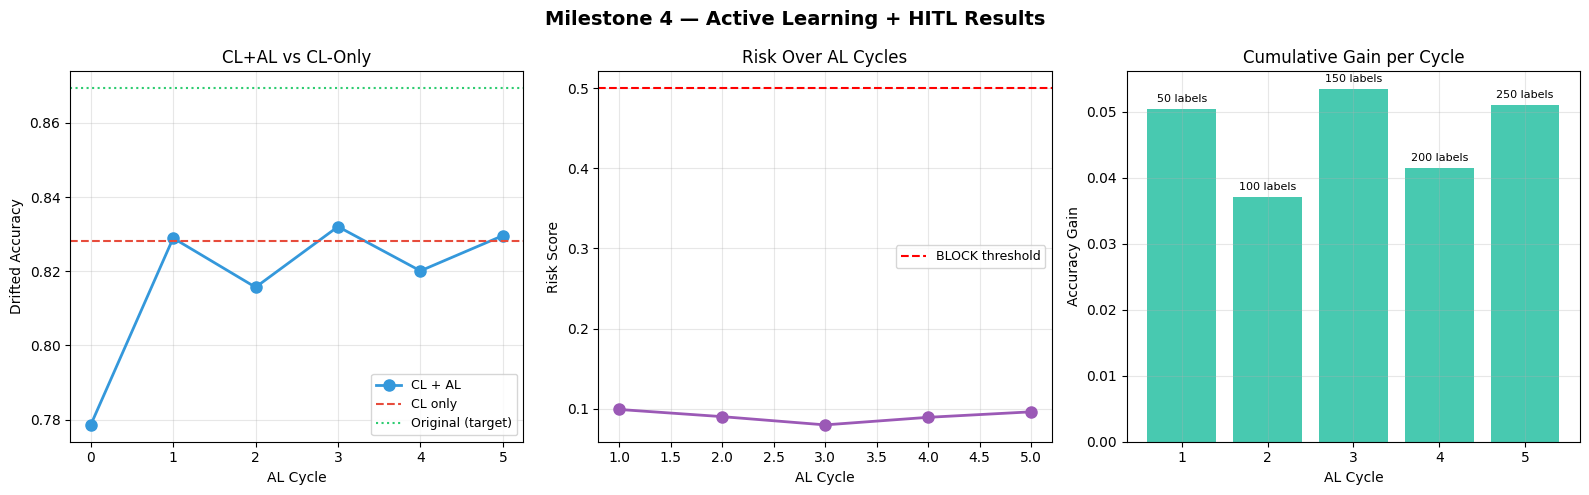

In [13]:

# 4.3 Active Learning Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Milestone 4 — Active Learning + HITL Results', fontsize=14, fontweight='bold')

cl_al_acc = [al_results[0]['drifted_acc']] + [r['drifted_acc'] for r in al_results[2:]]
axes[0].plot(range(len(cl_al_acc)), cl_al_acc, 'o-', color='#3498db', linewidth=2, markersize=8, label='CL + AL')
axes[0].axhline(y=al_results[1]['drifted_acc'], color='#e74c3c', linestyle='--', linewidth=1.5, label='CL only')
axes[0].axhline(y=al_results[0]['original_acc'], color='#2ecc71', linestyle=':', linewidth=1.5, label='Original (target)')
axes[0].set_xlabel('AL Cycle'); axes[0].set_ylabel('Drifted Accuracy')
axes[0].set_title('CL+AL vs CL-Only'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

risk_vals = [r['risk'] for r in al_results[2:]]
axes[1].plot(range(1, len(risk_vals)+1), risk_vals, 'o-', color='#9b59b6', linewidth=2, markersize=8)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='BLOCK threshold')
axes[1].set_xlabel('AL Cycle'); axes[1].set_ylabel('Risk Score')
axes[1].set_title('Risk Over AL Cycles'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

labels_used = [r['n_labeled'] for r in al_results[2:]]
acc_gained = [r['drifted_acc'] - al_results[0]['drifted_acc'] for r in al_results[2:]]
axes[2].bar(range(1, len(labels_used)+1), acc_gained, color='#1abc9c', alpha=0.8)
axes[2].set_xlabel('AL Cycle'); axes[2].set_ylabel('Accuracy Gain')
axes[2].set_title('Cumulative Gain per Cycle')
for i, (l, a) in enumerate(zip(labels_used, acc_gained)):
    axes[2].annotate(f'{l} labels', (i+1, a), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Neural Network Continual Learning Experiments

### 5.1 Image Classification — ResNet-18 on CIFAR-10

This validates replay-based CL on the image modality, where catastrophic forgetting in shared convolutional parameters is the core CL challenge. Unlike XGBoost (retrained from scratch), ResNet-18 fine-tuning updates shared weights, creating gradient interference and the stability–plasticity tension.


In [14]:

# 5.1a ResNet-18 Setup + Baseline Training
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

from torchvision.models import resnet18

def get_cifar_resnet18(num_classes=10):
    model = resnet18(weights=None, num_classes=num_classes)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

model_resnet = get_cifar_resnet18().to(device)
optimizer = optim.SGD(model_resnet.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

print("Training baseline ResNet-18 (20 epochs)...")
t0 = time.time()
for epoch in range(20):
    model_resnet.train()
    correct = 0; total = 0
    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model_resnet(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20: Acc={100.*correct/total:.2f}%")

train_time_resnet = time.time() - t0
print(f"Training complete in {train_time_resnet:.1f}s")

def evaluate_model(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return correct / total

clean_acc_resnet = evaluate_model(model_resnet, testloader)
print(f"\nBaseline ResNet-18 Clean Accuracy: {clean_acc_resnet:.4f}")
print(f"Peak VRAM: {torch.cuda.max_memory_allocated()/1e6:.0f} MB")


Device: cuda


100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


Training baseline ResNet-18 (20 epochs)...
  Epoch 5/20: Acc=78.20%
  Epoch 10/20: Acc=86.87%
  Epoch 15/20: Acc=93.08%
  Epoch 20/20: Acc=97.93%
Training complete in 858.8s

Baseline ResNet-18 Clean Accuracy: 0.9275
Peak VRAM: 825 MB


In [15]:
# ============================================================
# 5.1b ResNet-18 Adversarial Eval (FGSM)
# ============================================================

def fgsm_attack(model, images, labels, epsilon=0.04):
    images = images.clone().detach().requires_grad_(True)
    outputs = model(images)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()
    perturbed = images + epsilon * images.grad.sign()
    return perturbed.detach()

def adversarial_eval_resnet(model, loader, epsilon=0.04, max_batches=20):
    model.eval()
    clean_correct = 0; adv_correct = 0; total = 0; flipped = 0

    for i, (inputs, targets) in enumerate(loader):
        if i >= max_batches: break
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            clean_out = model(inputs)
            _, clean_pred = clean_out.max(1)
            clean_correct += clean_pred.eq(targets).sum().item()

        model.train()
        adv_inputs = fgsm_attack(model, inputs, targets, epsilon)
        model.eval()
        with torch.no_grad():
            adv_out = model(adv_inputs)
            _, adv_pred = adv_out.max(1)
            adv_correct += adv_pred.eq(targets).sum().item()

        correct_mask = clean_pred.eq(targets)
        flipped += (correct_mask & ~adv_pred.eq(targets)).sum().item()
        total += targets.size(0)

    clean_acc = clean_correct / total
    adv_acc = adv_correct / total
    asr = flipped / max(clean_correct, 1)
    risk = 0.35 * ((clean_acc - adv_acc) / max(clean_acc, 0.01)) + 0.25 * 0.05 + 0.25 * asr + 0.15 * min(asr * 1.2, 1.0)
    risk = max(0, min(1, risk))
    gate = "PASS" if risk < 0.5 else "BLOCK"
    return {'clean_acc': clean_acc, 'adv_acc': adv_acc, 'asr': asr, 'risk': risk, 'gate': gate}

baseline_adv_resnet = adversarial_eval_resnet(model_resnet, testloader, epsilon=0.04)
print(f"Baseline ResNet-18 FGSM (eps=0.04):")
print(f"  Clean={baseline_adv_resnet['clean_acc']:.4f}, Adv={baseline_adv_resnet['adv_acc']:.4f}, "
      f"ASR={baseline_adv_resnet['asr']:.4f}, Risk={baseline_adv_resnet['risk']:.4f} [{baseline_adv_resnet['gate']}]")


Baseline ResNet-18 FGSM (eps=0.04):
  Clean=0.9219, Adv=0.5516, ASR=0.4017, Risk=0.3258 [PASS]


In [16]:
# ============================================================
# 5.1c ResNet-18 CL — 3 Drift Events
# ============================================================
print("=" * 70)
print("RESNET-18 CONTINUAL LEARNING EXPERIMENT")
print("=" * 70)

class ImageReplayBuffer:
    def __init__(self, max_size=500):
        self.max_size = max_size
        self.images = []
        self.labels = []
    def initialize(self, dataset, n=500):
        indices = np.random.choice(len(dataset), min(n, len(dataset)), replace=False)
        for idx in indices:
            img, lbl = dataset[idx]
            self.images.append(img)
            self.labels.append(lbl)
        print(f"  Image buffer: {len(self.images)} samples")
    def update(self, new_images, new_labels, replace_frac=0.2):
        n_replace = int(len(self.images) * replace_frac)
        n_new = min(n_replace, len(new_images))
        ri = np.random.choice(len(self.images), n_new, replace=False)
        ni = np.random.choice(len(new_images), n_new, replace=False)
        for i, r in enumerate(ri):
            self.images[r] = new_images[ni[i]]
            self.labels[r] = new_labels[ni[i]]
    def get_dataset(self):
        return TensorDataset(torch.stack(self.images), torch.tensor(self.labels))

def apply_image_drift(dataset, mag=0.3):
    imgs, lbls = [], []
    for i in range(len(dataset)):
        img, lbl = dataset[i]
        img = img + mag * torch.randn(1).item() * 0.1
        mean = img.mean()
        img = (img - mean) * (1 + mag * 0.3) + mean
        img = torch.clamp(img, -3, 3)
        imgs.append(img); lbls.append(lbl)
    return imgs, lbls

def fine_tune_resnet(model, train_loader, epochs=2, lr=0.001):
    for name, param in model.named_parameters():
        if any(x in name for x in ['conv1', 'bn1', 'layer1', 'layer2']):
            param.requires_grad = False
        else:
            param.requires_grad = True
    opt = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9, weight_decay=5e-4)
    model.train()
    for epoch in range(epochs):
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            opt.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            opt.step()
    for param in model.parameters():
        param.requires_grad = True
    return model

buffer_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_test)
img_buffer = ImageReplayBuffer(max_size=500)
img_buffer.initialize(buffer_dataset)

test_dataset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

resnet_results = []
resnet_results.append({'stage': 'Baseline', 'clean_acc': baseline_adv_resnet['clean_acc'],
    'adv_acc': baseline_adv_resnet['adv_acc'], 'risk': baseline_adv_resnet['risk'],
    'gate': baseline_adv_resnet['gate'], 'update_time': 0, 'orig_acc': baseline_adv_resnet['clean_acc']})
print(f"Baseline: Clean={baseline_adv_resnet['clean_acc']:.4f}, Risk={baseline_adv_resnet['risk']:.4f}")

for i, mag in enumerate([0.3, 0.5, 0.8]):
    print(f"\n--- Drift {i+1} (mag={mag}) ---")
    drifted_imgs, drifted_lbls = apply_image_drift(test_dataset_raw, mag)
    drifted_ds = TensorDataset(torch.stack(drifted_imgs), torch.tensor(drifted_lbls))
    drifted_loader = DataLoader(drifted_ds, batch_size=128, shuffle=False)

    drift_acc_before = evaluate_model(model_resnet, drifted_loader)
    orig_acc_before = evaluate_model(model_resnet, testloader)
    adv_before = adversarial_eval_resnet(model_resnet, testloader, epsilon=0.04)
    resnet_results.append({'stage': f'Drift {i+1} (before)', 'clean_acc': drift_acc_before,
        'adv_acc': adv_before['adv_acc'], 'risk': adv_before['risk'], 'gate': adv_before['gate'],
        'update_time': 0, 'orig_acc': orig_acc_before})
    print(f"  Before: Drifted={drift_acc_before:.4f}, Orig={orig_acc_before:.4f}, Risk={adv_before['risk']:.4f}")

    buffer_ds = img_buffer.get_dataset()
    train_drift_imgs, train_drift_lbls = apply_image_drift(
        Subset(buffer_dataset, np.random.choice(len(buffer_dataset), 200, replace=False)), mag)
    new_ds = TensorDataset(torch.stack(train_drift_imgs), torch.tensor(train_drift_lbls))
    combined_ds = ConcatDataset([buffer_ds, new_ds])
    cl_loader = DataLoader(combined_ds, batch_size=64, shuffle=True)

    t0 = time.time()
    model_resnet = fine_tune_resnet(model_resnet, cl_loader, epochs=2, lr=0.001)
    update_time = time.time() - t0

    drift_acc_after = evaluate_model(model_resnet, drifted_loader)
    orig_acc_after = evaluate_model(model_resnet, testloader)
    adv_after = adversarial_eval_resnet(model_resnet, testloader, epsilon=0.04)
    resnet_results.append({'stage': f'Drift {i+1} (after)', 'clean_acc': drift_acc_after,
        'adv_acc': adv_after['adv_acc'], 'risk': adv_after['risk'], 'gate': adv_after['gate'],
        'update_time': update_time, 'orig_acc': orig_acc_after})
    print(f"  After:  Drifted={drift_acc_after:.4f}, Orig={orig_acc_after:.4f}, Risk={adv_after['risk']:.4f}, Time={update_time:.1f}s")
    img_buffer.update(train_drift_imgs[:100], train_drift_lbls[:100])

print("\n" + "=" * 70)
print("RESNET-18 CL SUMMARY")
print("=" * 70)
print(f"{'Stage':<22} {'Drifted':>10} {'Original':>10} {'Adv Acc':>10} {'Risk':>8} {'Gate':>6} {'Time':>8}")
print("-" * 76)
for r in resnet_results:
    print(f"{r['stage']:<22} {r['clean_acc']:>10.4f} {r['orig_acc']:>10.4f} "
          f"{r['adv_acc']:>10.4f} {r['risk']:>8.4f} {r['gate']:>6} {r['update_time']:>7.1f}s")

print("\nBackward Transfer (Forgetting):")
for i in range(1, len(resnet_results)):
    if 'after' in resnet_results[i]['stage']:
        j = i - 1
        bwt = resnet_results[i]['orig_acc'] - resnet_results[j]['orig_acc']
        print(f"  {resnet_results[i]['stage']}: BWT = {bwt:+.4f}")


RESNET-18 CONTINUAL LEARNING EXPERIMENT
  Image buffer: 500 samples
Baseline: Clean=0.9219, Risk=0.3258

--- Drift 1 (mag=0.3) ---
  Before: Drifted=0.9106, Orig=0.9186, Risk=0.3382
  After:  Drifted=0.9072, Orig=0.9145, Risk=0.3376, Time=0.6s

--- Drift 2 (mag=0.5) ---
  Before: Drifted=0.8929, Orig=0.9126, Risk=0.3364
  After:  Drifted=0.9044, Orig=0.9168, Risk=0.3384, Time=0.6s

--- Drift 3 (mag=0.8) ---
  Before: Drifted=0.8783, Orig=0.9132, Risk=0.3406
  After:  Drifted=0.9001, Orig=0.9204, Risk=0.3347, Time=0.6s

RESNET-18 CL SUMMARY
Stage                     Drifted   Original    Adv Acc     Risk   Gate     Time
----------------------------------------------------------------------------
Baseline                   0.9219     0.9219     0.5516   0.3258   PASS     0.0s
Drift 1 (before)           0.9106     0.9186     0.5312   0.3382   PASS     0.0s
Drift 1 (after)            0.9072     0.9145     0.5309   0.3376   PASS     0.6s
Drift 2 (before)           0.8929     0.9126     0.53

### 5.2 NLP Sentiment — DistilBERT on SST-2

Validates replay-based CL on a transformer where pre-trained contextual representations provide intrinsic robustness. The CL challenge: preserving pre-trained knowledge while adapting to shifted text distributions.


In [18]:
# ============================================================
# 5.2a DistilBERT Setup + Baseline
# ============================================================
!pip install transformers datasets -q

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from datasets import load_dataset
import random, string

print("Loading SST-2...")
dataset = load_dataset("glue", "sst2")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_data(texts, labels, max_len=128):
    enc = tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors='pt')
    return TensorDataset(enc['input_ids'], enc['attention_mask'], torch.tensor(labels))



train_texts = list(dataset['train']['sentence'][:5000])
train_labels = list(dataset['train']['label'][:5000])
test_texts = list(dataset['validation']['sentence'])
test_labels = list(dataset['validation']['label'])

train_ds_bert = tokenize_data(train_texts, train_labels)
test_ds_bert = tokenize_data(test_texts, test_labels)
train_loader_bert = DataLoader(train_ds_bert, batch_size=16, shuffle=True)
test_loader_bert = DataLoader(test_ds_bert, batch_size=32, shuffle=False)

print(f"Train: {len(train_ds_bert)}, Test: {len(test_ds_bert)}")

model_bert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
opt_bert = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

print("Fine-tuning DistilBERT (3 epochs)...")
t0 = time.time()
for epoch in range(3):
    model_bert.train()
    correct = 0; total = 0
    for batch in train_loader_bert:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        opt_bert.zero_grad()
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        opt_bert.step()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    print(f"  Epoch {epoch+1}/3: Acc={100*correct/total:.2f}%")

bert_train_time = time.time() - t0

def evaluate_bert(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

bert_clean_acc = evaluate_bert(model_bert, test_loader_bert)
print(f"\nBaseline DistilBERT Accuracy: {bert_clean_acc:.4f} ({bert_train_time:.1f}s)")


Loading SST-2...
Train: 5000, Test: 872


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT (3 epochs)...
  Epoch 1/3: Acc=84.14%
  Epoch 2/3: Acc=94.20%
  Epoch 3/3: Acc=97.44%

Baseline DistilBERT Accuracy: 0.8853 (172.6s)


In [19]:
# ============================================================
# 5.2b DistilBERT Adversarial + CL Experiment
# ============================================================

def char_perturb(text, rate=0.1):
    chars = list(text)
    n_perturb = max(1, int(len(chars) * rate))
    for _ in range(n_perturb):
        idx = random.randint(0, max(0, len(chars) - 1))
        op = random.choice(['swap', 'insert', 'delete'])
        if op == 'swap' and idx < len(chars):
            chars[idx] = random.choice(string.ascii_lowercase)
        elif op == 'insert':
            chars.insert(idx, random.choice(string.ascii_lowercase))
        elif op == 'delete' and len(chars) > 1:
            chars.pop(idx)
    return ''.join(chars)

def adversarial_eval_bert(model, texts, labels, rate=0.1, n=200):
    model.eval()
    idx = np.random.choice(len(texts), min(n, len(texts)), replace=False)
    clean_c = 0; adv_c = 0; flipped = 0
    for i in idx:
        enc = tokenizer(texts[i], truncation=True, padding='max_length', max_length=128, return_tensors='pt')
        with torch.no_grad():
            out = model(input_ids=enc['input_ids'].to(device), attention_mask=enc['attention_mask'].to(device))
            cp = out.logits.argmax(dim=-1).item()
        enc_p = tokenizer(char_perturb(texts[i], rate), truncation=True, padding='max_length', max_length=128, return_tensors='pt')
        with torch.no_grad():
            out_p = model(input_ids=enc_p['input_ids'].to(device), attention_mask=enc_p['attention_mask'].to(device))
            ap = out_p.logits.argmax(dim=-1).item()
        if cp == labels[i]:
            clean_c += 1
            if ap != labels[i]: flipped += 1
        if ap == labels[i]: adv_c += 1
    ca = clean_c / len(idx); aa = adv_c / len(idx)
    asr = flipped / max(clean_c, 1)
    risk = 0.35 * ((ca - aa) / max(ca, 0.01)) + 0.25 * 0.02 + 0.25 * asr + 0.15 * asr
    risk = max(0, min(1, risk))
    return {'clean_acc': ca, 'adv_acc': aa, 'asr': asr, 'risk': risk, 'gate': "PASS" if risk < 0.5 else "BLOCK"}

def apply_text_drift(texts, mag=0.3):
    replacements = {'good': ['decent', 'fine', 'solid'], 'bad': ['poor', 'awful', 'weak'],
        'great': ['excellent', 'superb', 'outstanding'], 'terrible': ['horrible', 'dreadful'],
        'love': ['adore', 'enjoy', 'appreciate'], 'hate': ['despise', 'loathe'],
        'movie': ['film', 'picture', 'flick'], 'funny': ['humorous', 'amusing'],
        'boring': ['dull', 'tedious'], 'beautiful': ['gorgeous', 'stunning']}
    drifted = []
    for text in texts:
        words = text.split()
        n_changes = max(1, int(len(words) * mag * 0.3))
        for _ in range(n_changes):
            idx = random.randint(0, len(words) - 1)
            w = words[idx].lower().strip('.,!?')
            if w in replacements: words[idx] = random.choice(replacements[w])
            elif random.random() < mag * 0.2: words[idx] = char_perturb(words[idx], 0.15)
        drifted.append(' '.join(words))
    return drifted

print("=" * 70)
print("DISTILBERT CONTINUAL LEARNING EXPERIMENT")
print("=" * 70)

class NLPReplayBuffer:
    def __init__(self, max_size=500):
        self.texts = []; self.labels = []
    def initialize(self, texts, labels, n=500):
        idx = np.random.choice(len(texts), min(n, len(texts)), replace=False)
        self.texts = [texts[i] for i in idx]; self.labels = [labels[i] for i in idx]
        print(f"  NLP buffer: {len(self.texts)} samples")
    def update(self, new_texts, new_labels, replace_frac=0.2):
        nr = int(len(self.texts) * replace_frac); nn = min(nr, len(new_texts))
        ri = np.random.choice(len(self.texts), nn, replace=False)
        ni = np.random.choice(len(new_texts), nn, replace=False)
        for i, r in enumerate(ri): self.texts[r] = new_texts[ni[i]]; self.labels[r] = new_labels[ni[i]]
    def get_dataset(self):
        return tokenize_data(self.texts, self.labels)

nlp_buffer = NLPReplayBuffer()
nlp_buffer.initialize(train_texts, train_labels)

bert_adv_base = adversarial_eval_bert(model_bert, test_texts, test_labels)
bert_results = []
bert_results.append({'stage': 'Baseline', 'clean_acc': bert_adv_base['clean_acc'],
    'adv_acc': bert_adv_base['adv_acc'], 'risk': bert_adv_base['risk'],
    'gate': bert_adv_base['gate'], 'update_time': 0, 'orig_acc': bert_clean_acc})
print(f"Baseline: Clean={bert_clean_acc:.4f}, Risk={bert_adv_base['risk']:.4f}")

for i, mag in enumerate([0.3, 0.5, 0.8]):
    print(f"\n--- Drift {i+1} (mag={mag}) ---")
    drifted_test = apply_text_drift(test_texts, mag)
    drifted_test_ds = tokenize_data(drifted_test, test_labels)
    drifted_test_loader = DataLoader(drifted_test_ds, batch_size=32, shuffle=False)

    drift_acc_b = evaluate_bert(model_bert, drifted_test_loader)
    orig_acc_b = evaluate_bert(model_bert, test_loader_bert)
    adv_b = adversarial_eval_bert(model_bert, test_texts, test_labels)
    bert_results.append({'stage': f'Drift {i+1} (before)', 'clean_acc': drift_acc_b,
        'adv_acc': adv_b['adv_acc'], 'risk': adv_b['risk'], 'gate': adv_b['gate'],
        'update_time': 0, 'orig_acc': orig_acc_b})
    print(f"  Before: Drifted={drift_acc_b:.4f}, Orig={orig_acc_b:.4f}")

    drifted_train = apply_text_drift(train_texts[:300], mag)
    drifted_train_labels = train_labels[:300]
    buf_ds = nlp_buffer.get_dataset()
    new_ds = tokenize_data(drifted_train, drifted_train_labels)
    cl_ds = ConcatDataset([buf_ds, new_ds])
    cl_loader = DataLoader(cl_ds, batch_size=16, shuffle=True)

    t0 = time.time()
    model_bert.train()
    opt_cl = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)
    for batch in cl_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        opt_cl.zero_grad()
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        opt_cl.step()
    update_time = time.time() - t0

    drift_acc_a = evaluate_bert(model_bert, drifted_test_loader)
    orig_acc_a = evaluate_bert(model_bert, test_loader_bert)
    adv_a = adversarial_eval_bert(model_bert, test_texts, test_labels)
    bert_results.append({'stage': f'Drift {i+1} (after)', 'clean_acc': drift_acc_a,
        'adv_acc': adv_a['adv_acc'], 'risk': adv_a['risk'], 'gate': adv_a['gate'],
        'update_time': update_time, 'orig_acc': orig_acc_a})
    print(f"  After:  Drifted={drift_acc_a:.4f}, Orig={orig_acc_a:.4f}, Risk={adv_a['risk']:.4f}, Time={update_time:.1f}s")
    nlp_buffer.update(drifted_train[:100], drifted_train_labels[:100])

print("\n" + "=" * 70)
print("DISTILBERT CL SUMMARY")
print("=" * 70)
print(f"{'Stage':<22} {'Drifted':>10} {'Original':>10} {'Risk':>8} {'Gate':>6} {'Time':>8}")
print("-" * 60)
for r in bert_results:
    print(f"{r['stage']:<22} {r['clean_acc']:>10.4f} {r['orig_acc']:>10.4f} {r['risk']:>8.4f} {r['gate']:>6} {r['update_time']:>7.1f}s")

print("\nBackward Transfer:")
for i in range(1, len(bert_results)):
    if 'after' in bert_results[i]['stage']:
        j = i - 1
        bwt = bert_results[i]['orig_acc'] - bert_results[j]['orig_acc']
        print(f"  {bert_results[i]['stage']}: BWT = {bwt:+.4f}")


DISTILBERT CONTINUAL LEARNING EXPERIMENT
  NLP buffer: 500 samples
Baseline: Clean=0.8853, Risk=0.2168

--- Drift 1 (mag=0.3) ---
  Before: Drifted=0.8819, Orig=0.8853
  After:  Drifted=0.8807, Orig=0.8819, Risk=0.1399, Time=9.1s

--- Drift 2 (mag=0.5) ---
  Before: Drifted=0.8773, Orig=0.8819
  After:  Drifted=0.8693, Orig=0.8739, Risk=0.1607, Time=9.0s

--- Drift 3 (mag=0.8) ---
  Before: Drifted=0.8635, Orig=0.8739
  After:  Drifted=0.8452, Orig=0.8532, Risk=0.1601, Time=8.9s

DISTILBERT CL SUMMARY
Stage                     Drifted   Original     Risk   Gate     Time
------------------------------------------------------------
Baseline                   0.8900     0.8853   0.2168   PASS     0.0s
Drift 1 (before)           0.8819     0.8853   0.1655   PASS     0.0s
Drift 1 (after)            0.8807     0.8819   0.1399   PASS     9.1s
Drift 2 (before)           0.8773     0.8819   0.1821   PASS     0.0s
Drift 2 (after)            0.8693     0.8739   0.1607   PASS     9.0s
Drift 3 (bef

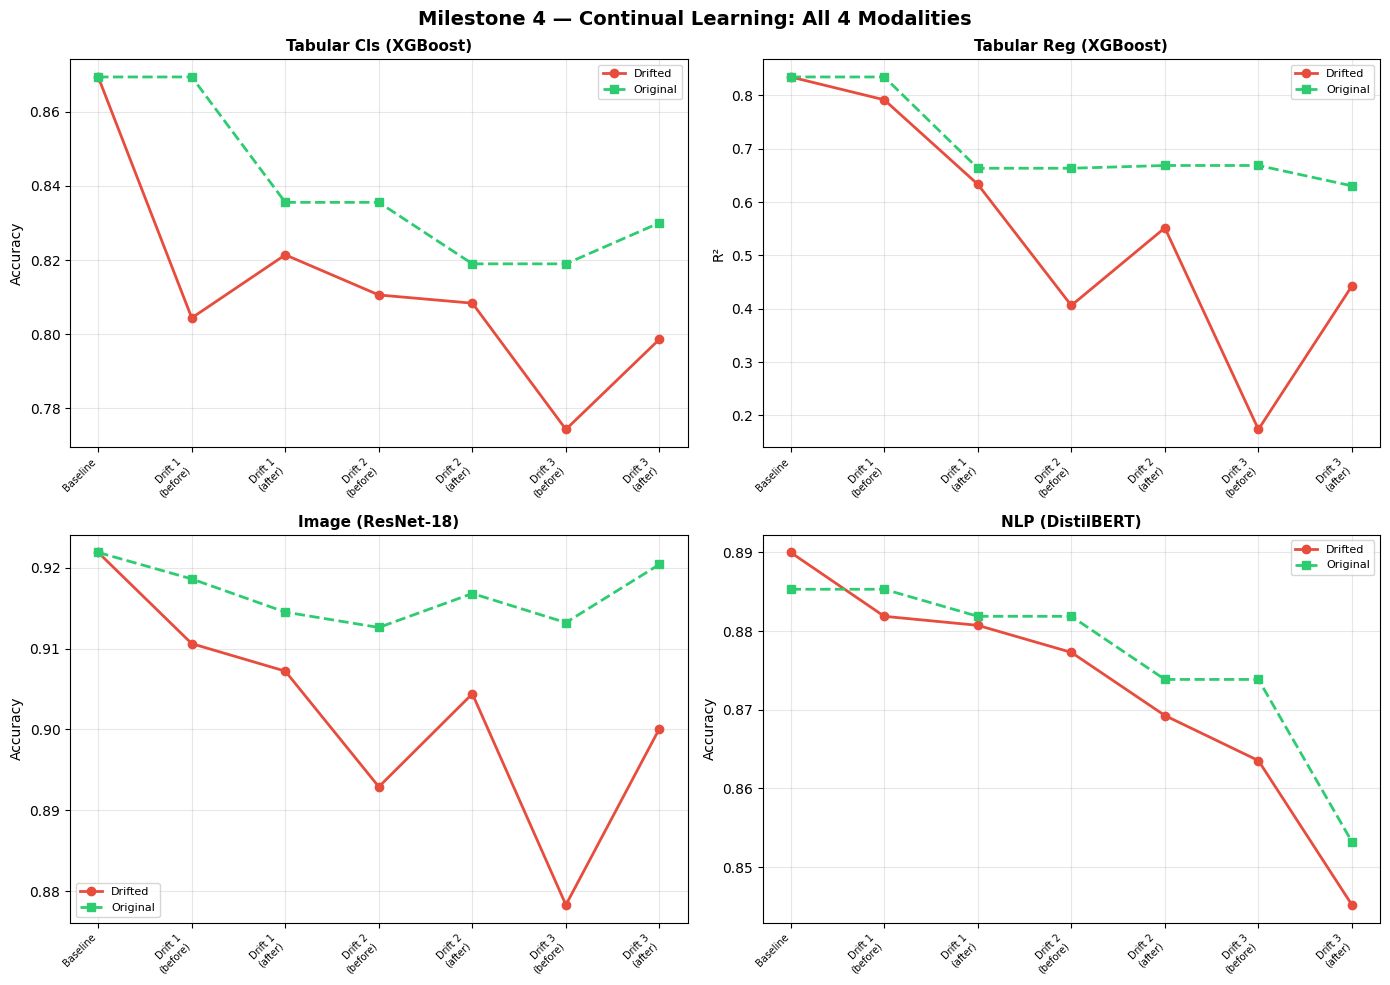


CROSS-MODALITY FORGETTING ANALYSIS
Modality                           Baseline        Final     Cum. BWT
--------------------------------------------------------------------
Tab Cls (XGBoost)                    0.8694       0.8301      -0.0393
Tab Reg (XGBoost)                    0.8346       0.6303      -0.2043
Image (ResNet-18)                    0.9219       0.9204      -0.0015
NLP (DistilBERT)                     0.8853       0.8532      -0.0321

Tree-based forgetting = data support loss (no shared params)
Neural forgetting = gradient interference in shared weights (stability-plasticity)


In [20]:
# ============================================================
# 5.3 Cross-Modality CL Visualization + Forgetting Analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Milestone 4 — Continual Learning: All 4 Modalities', fontsize=14, fontweight='bold')

def plot_mod(ax, results, title, mk='clean_acc', ok='orig_acc', yl='Accuracy'):
    stages = [r['stage'] for r in results]; x = range(len(stages))
    ax.plot(x, [r[mk] for r in results], 'o-', color='#e74c3c', linewidth=2, label='Drifted')
    if ok: ax.plot(x, [r[ok] for r in results], 's--', color='#2ecc71', linewidth=2, label='Original')
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.set_xticks(x)
    ax.set_xticklabels([s.replace(' (', '\n(') for s in stages], fontsize=7, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)

plot_mod(axes[0, 0], cls_results, 'Tabular Cls (XGBoost)', 'drifted_acc', 'original_acc')
plot_mod(axes[0, 1], reg_results, 'Tabular Reg (XGBoost)', 'drifted_r2', 'original_r2', 'R\u00B2')
plot_mod(axes[1, 0], resnet_results, 'Image (ResNet-18)', 'clean_acc', 'orig_acc')
plot_mod(axes[1, 1], bert_results, 'NLP (DistilBERT)', 'clean_acc', 'orig_acc')

plt.tight_layout()
plt.show()

# Forgetting table
def cum_bwt(results, ok='orig_acc'):
    b = results[0][ok]
    f = None
    for r in results:
        if 'after' in r.get('stage', ''): f = r[ok]
    return (f - b) if f is not None else 0

print("\n" + "=" * 70)
print("CROSS-MODALITY FORGETTING ANALYSIS")
print("=" * 70)
print(f"{'Modality':<30} {'Baseline':>12} {'Final':>12} {'Cum. BWT':>12}")
print("-" * 68)
print(f"{'Tab Cls (XGBoost)':<30} {cls_results[0]['original_acc']:>12.4f} {cls_results[-1]['original_acc']:>12.4f} {cum_bwt(cls_results, 'original_acc'):>+12.4f}")
print(f"{'Tab Reg (XGBoost)':<30} {reg_results[0]['original_r2']:>12.4f} {reg_results[-1]['original_r2']:>12.4f} {cum_bwt(reg_results, 'original_r2'):>+12.4f}")
print(f"{'Image (ResNet-18)':<30} {resnet_results[0]['orig_acc']:>12.4f} {resnet_results[-1]['orig_acc']:>12.4f} {cum_bwt(resnet_results, 'orig_acc'):>+12.4f}")
print(f"{'NLP (DistilBERT)':<30} {bert_results[0]['orig_acc']:>12.4f} {bert_results[-1]['orig_acc']:>12.4f} {cum_bwt(bert_results, 'orig_acc'):>+12.4f}")
print("\nTree-based forgetting = data support loss (no shared params)")
print("Neural forgetting = gradient interference in shared weights (stability-plasticity)")


## 6. End-to-End Pipeline Demo
**Full pipeline**: Load → Infer → Detect Drift → Query Human → Update Model → Re-evaluate


In [21]:
# ============================================================
# 6. END-TO-END PIPELINE DEMO
# ============================================================
print("=" * 70)
print("END-TO-END PIPELINE DEMO")
print("Load -> Infer -> Detect Drift -> Query Human -> Update Model")
print("=" * 70)

print("\n[Step 1] Loading model and test data...")
demo_model = clf_baseline
print(f"  Model: XGBoost Classifier, Test: {len(X_test_cls)} samples")

print("\n[Step 2] Inference on clean data...")
print(f"  Clean accuracy: {accuracy_score(y_test_cls, demo_model.predict(X_test_cls)):.4f}")

print("\n[Step 3] Simulating production batch (+0.5\u03C3 shift)...")
X_prod = X_test_cls.copy()
for i in range(6): X_prod[:, i] += 0.5 * np.std(X_test_cls[:, i])

print("\n[Step 4] Drift detection (PSI)...")
dd, mp, nf = detect_drift(X_test_cls, X_prod)
print(f"  PSI={mp:.4f}, Drifted features={nf}, Detected={dd}")

if dd:
    print("\n  \u26A0\uFE0F  DRIFT ALERT")
    print("\n[Step 5] Human validates: genuine shift confirmed")
    print("\n[Step 6] Active Learning: selecting 50 samples...")
    al_demo = ActiveLearner(budget=50)
    sel_idx, qt = al_demo.select_samples(demo_model, X_prod)
    print(f"  Selected {len(sel_idx)} samples ({qt:.3f}s)")

    print("\n[Step 7] Human annotation (simulated)...")
    y_ann = y_test_cls[sel_idx].copy()

    print("\n[Step 8] CL update with replay buffer...")
    cl_demo = ContinualLearner(task_type='classification')
    cl_demo.initialize(demo_model, X_train_cls, y_train_cls)
    cl_demo.buffer.update(X_prod[sel_idx], y_ann, human_verified=True)
    idx = np.random.choice(len(X_prod), 300, replace=False)
    ut = cl_demo.retrain(X_prod[idx], y_test_cls[idx])
    print(f"  Retrained in {ut:.2f}s")

    print("\n[Step 9] Adversarial re-evaluation...")
    risk = compute_classification_risk(cl_demo.model, X_test_cls, y_test_cls)
    print(f"  Risk: {risk['risk_score']:.4f} -> {risk['gate']}")

    print(f"\n[Step 10] Deployment: {risk['gate']}")
    if risk['gate'] == 'PASS':
        print(f"  \u2705 Deployed! Acc={accuracy_score(y_test_cls, cl_demo.model.predict(X_prod)):.4f}")
    else:
        print("  \u274C BLOCK - rollback")

print("\n" + "=" * 70)
print("END-TO-END DEMO COMPLETE")
print("=" * 70)


END-TO-END PIPELINE DEMO
Load -> Infer -> Detect Drift -> Query Human -> Update Model

[Step 1] Loading model and test data...
  Model: XGBoost Classifier, Test: 4525 samples

[Step 2] Inference on clean data...
  Clean accuracy: 0.8694

[Step 3] Simulating production batch (+0.5σ shift)...

[Step 4] Drift detection (PSI)...
  PSI=0.3362, Drifted features=4, Detected=True

  ⚠️  DRIFT ALERT

[Step 5] Human validates: genuine shift confirmed

[Step 6] Active Learning: selecting 50 samples...
  Selected 50 samples (0.209s)

[Step 7] Human annotation (simulated)...

[Step 8] CL update with replay buffer...
  Buffer initialized: 500 samples, version 1
  ContinualLearner initialized (classification)
  Retrained in 0.85s

[Step 9] Adversarial re-evaluation...
  Risk: 0.1105 -> PASS

[Step 10] Deployment: PASS
  ✅ Deployed! Acc=0.8466

END-TO-END DEMO COMPLETE
